# Clase 4 — Redes convolucionales y entrenamiento

Hasta ahora hemos trabajado con técnicas clásicas de visión artificial basadas en filtros, transformaciones geométricas y descriptores diseñados manualmente (como SIFT u ORB). Aunque estos métodos siguen siendo muy útiles, presentan una limitación importante: requieren que un experto defina explícitamente qué características son relevantes para resolver un problema.

Las **Redes Neuronales Convolucionales (CNNs)** cambiaron este paradigma al permitir que el propio modelo aprenda automáticamente las representaciones más útiles directamente a partir de los datos. En lugar de diseñar manualmente detectores de bordes, esquinas o texturas, una CNN aprende una jerarquía de características que va desde patrones simples hasta conceptos complejos.

## Contenidos

* Capas convolucionales y de pooling
* Entrenamiento de arquitecturas
    - LeNet
    - VGG
    - ResNet
* Dataset Augmentation
* Transfer learning y Fine tuning
* Métricas y evaluación de desempeño

---

## 0. Imports y configuración

In [15]:
import random
from time import time
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.color import rgb2gray

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from scipy.ndimage import convolve

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Configuración gráfica
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "gray"

# Reproducibilidad
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Dispositivo utilizado: {DEVICE}")

Dispositivo utilizado: cpu


---
# 1. Capas convolucionales

La idea fundamental de una **Red Neuronal Convolucional (Convolutional Neural Network, CNN)** consiste en reemplazar la ingeniería manual de características por un proceso de **aprendizaje automático de filtros**.

En visión artificial clásica utilizábamos operadores como Sobel, Prewitt o Laplaciano para detectar bordes, esquinas o regiones de interés. Cada uno de estos filtros había sido diseñado específicamente para una tarea determinada. Una CNN parte del mismo principio: aplicar pequeños filtros sobre toda la imagen. Sin embargo, en lugar de fijar previamente sus valores, **los pesos de cada filtro se ajustan automáticamente mediante backpropagation**, permitiendo que la red descubra por sí misma qué patrones son útiles para resolver el problema.

Cada filtro produce una nueva imagen denominada **mapa de activación (feature map)**. Si un filtro responde fuertemente a un determinado patrón (por ejemplo, un borde horizontal), dicho patrón aparecerá resaltado en el mapa de activación.

Shape de entrada: torch.Size([1, 1, 512, 512])
Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
torch.Size([1, 8, 512, 512])
(8, 1, 3, 3)


C:\Users\JuanI\AppData\Local\Temp\ipykernel_31692\3716405850.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


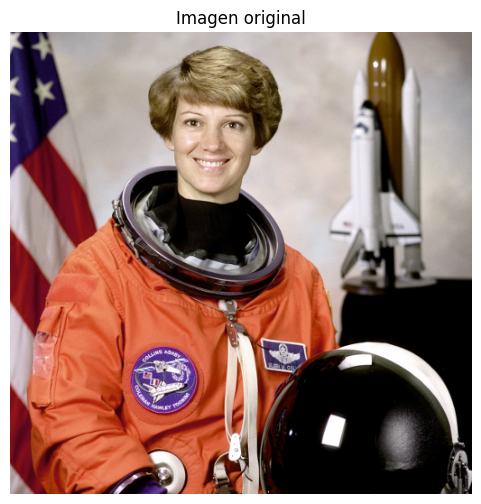

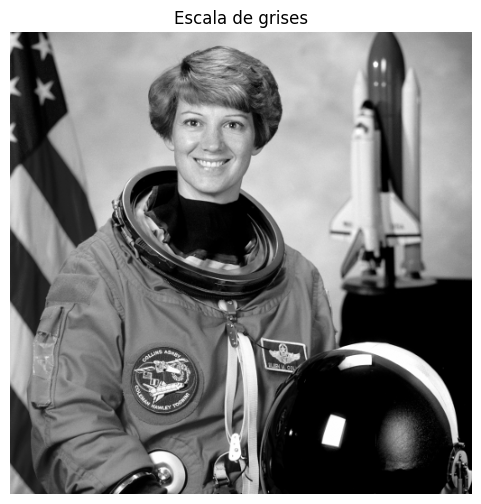

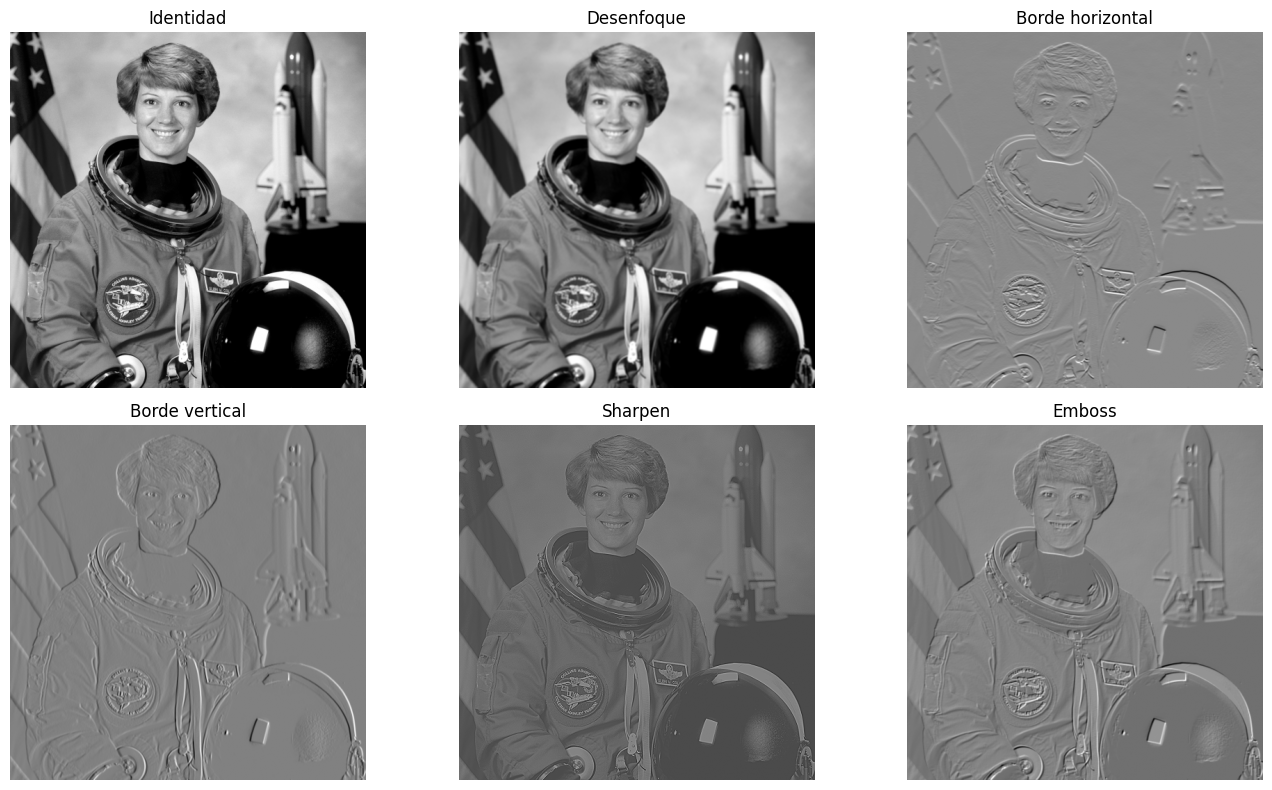

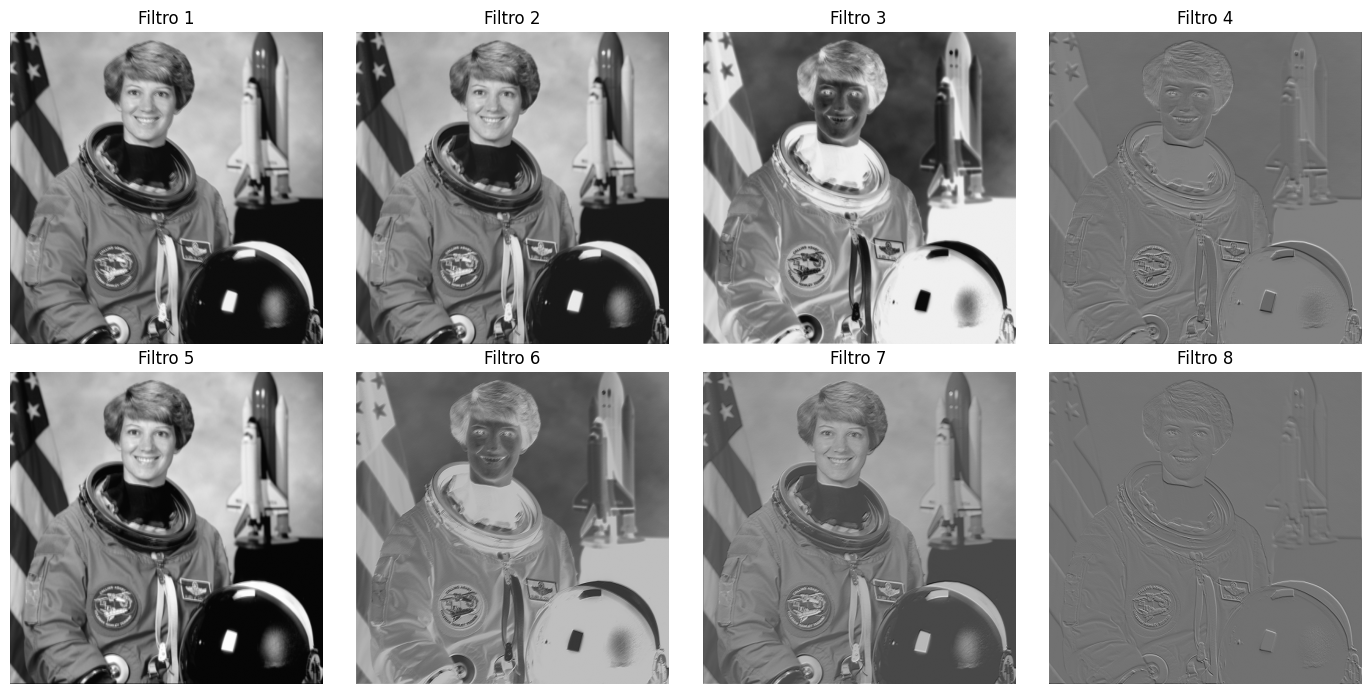

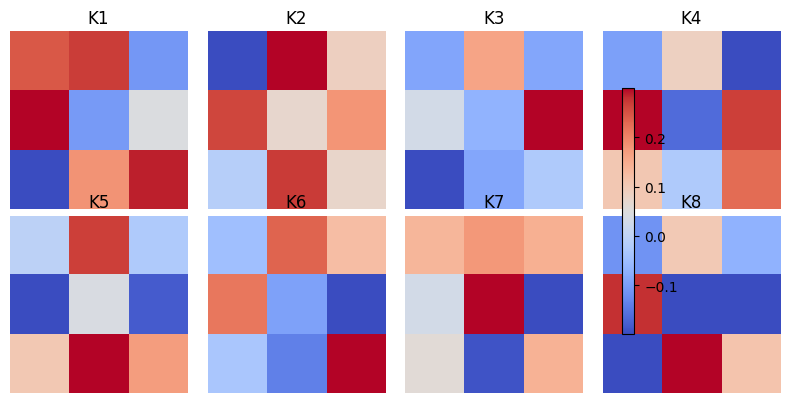

In [16]:
# ==========================================================
# Imagen de ejemplo
# ==========================================================
image = data.astronaut()

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Imagen original")
plt.axis("off");

gray = rgb2gray(image)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap="gray")
plt.title("Escala de grises")
plt.axis("off");

kernels = {
    "Identidad": np.array([
        [0,0,0],
        [0,1,0],
        [0,0,0]
    ]),

    "Desenfoque": np.ones((3,3))/9,

    "Borde horizontal": np.array([
        [-1,-2,-1],
        [ 0, 0, 0],
        [ 1, 2, 1]
    ]),

    "Borde vertical": np.array([
        [-1,0,1],
        [-2,0,2],
        [-1,0,1]
    ]),

    "Sharpen": np.array([
        [ 0,-1,0],
        [-1,5,-1],
        [ 0,-1,0]
    ]),

    "Emboss": np.array([
        [-2,-1,0],
        [-1,1,1],
        [0,1,2]
    ])
}

fig, axes = plt.subplots(2, 3, figsize=(14,8))

for ax, (name, kernel) in zip(axes.ravel(), kernels.items()):

    filtered = convolve(gray, kernel)

    ax.imshow(filtered, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()

# ==========================================================
# Una capa convolucional en PyTorch
# ==========================================================
# Imagen -> Tensor
img = torch.tensor(gray, dtype=torch.float32)

# Añadimos:
# Batch dimension = 1
# Channel dimension = 1 (escala de grises)

img = img.unsqueeze(0).unsqueeze(0)

print("Shape de entrada:", img.shape)

# ==========================================================
# Definimos una capa convolucional
# ==========================================================

conv = nn.Conv2d(
    in_channels=1,
    out_channels=8,     # aprenderá 8 filtros distintos
    kernel_size=3,
    stride=1,
    padding=1
)

print(conv)

# ==========================================================
# Aplicamos la convolución
# ==========================================================

with torch.no_grad():
    feature_maps = conv(img)

print(feature_maps.shape)

# ==========================================================
# Visualizamos los feature maps
# ==========================================================

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.ravel()):
    fmap = feature_maps[0, i].numpy()

    ax.imshow(fmap)
    ax.set_title(f"Filtro {i+1}")
    ax.axis("off")

plt.tight_layout()

# ==========================================================
# Pesos aprendibles de la capa
# ==========================================================

weights = conv.weight.detach().numpy()

print(weights.shape)

# ==========================================================
# Visualización de los kernels
# ==========================================================

fig, axes = plt.subplots(2, 4, figsize=(8,4))

for i, ax in enumerate(axes.ravel()):
    kernel = weights[i, 0]

    im = ax.imshow(kernel, cmap="coolwarm")
    ax.set_title(f"K{i+1}")
    ax.axis("off")

plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()

---
# 2. Capas de Pooling

Las capas convolucionales generan mapas de activación que resaltan distintos patrones presentes en la imagen. Sin embargo, estos mapas conservan prácticamente la misma resolución espacial que la imagen original, lo que implica un elevado costo computacional en las capas posteriores para guardar información que no siempre aporta valor adicional.

Las **capas de pooling** reducen la resolución de los mapas de activación resumiendo la información contenida en pequeñas regiones de la imagen. De esta forma se consigue:

- Reducir el número de datos que procesa la red.
- Disminuir el costo computacional y la memoria requerida.
- Hacer que la representación sea más robusta frente a pequeñas traslaciones o deformaciones.
- Reducir el riesgo de sobreajuste.

A diferencia de las capas convolucionales, **el pooling no posee parámetros entrenables**. Su funcionamiento es completamente determinístico. En la fase de backpropagation estas capas son atravesadas sin ningún cambio, de modo que no tienen costo adicional.

Las dos variantes más utilizadas son:

- **Max Pooling**, que conserva únicamente el valor máximo de cada región.
- **Average Pooling**, que reemplaza la región por su valor promedio.

Antes : torch.Size([1, 8, 512, 512])
Después: torch.Size([1, 8, 10, 10])


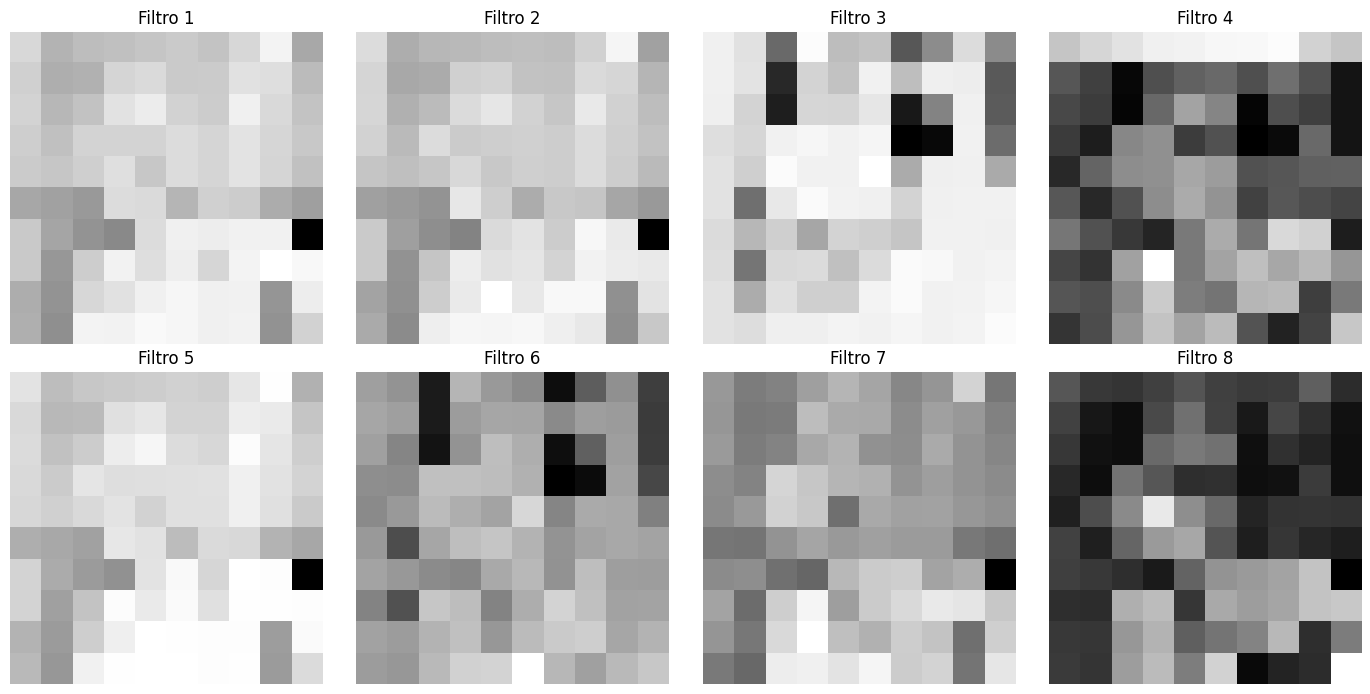

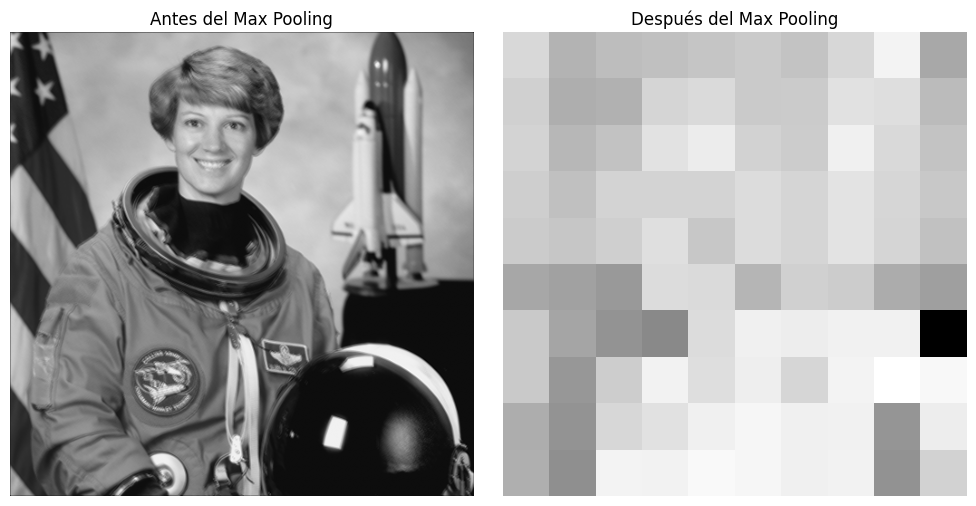

In [17]:
# ==========================================================
# Max Pooling
# ==========================================================

pool = nn.MaxPool2d(
    kernel_size=50,
    stride=50
)

with torch.no_grad():
    pooled_maps = pool(feature_maps)

print("Antes :", feature_maps.shape)
print("Después:", pooled_maps.shape)

fig, axes = plt.subplots(2, 4, figsize=(14,7))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(pooled_maps[0, i].numpy())
    ax.set_title(f"Filtro {i+1}")
    ax.axis("off")

plt.tight_layout()

# Elegimos un feature map
idx = 0

fig, axes = plt.subplots(1,2, figsize=(10,5))

axes[0].imshow(feature_maps[0, idx].numpy())
axes[0].set_title("Antes del Max Pooling")
axes[0].axis("off")

axes[1].imshow(pooled_maps[0, idx].numpy())
axes[1].set_title("Después del Max Pooling")
axes[1].axis("off")

plt.tight_layout()

---
# 3. Primera arquitectura convolucional: LeNet-5

Hasta ahora hemos estudiado de forma aislada las capas convolucionales y de pooling. Sin embargo, una red neuronal convolucional está formada por la combinación de estos bloques para extraer características cada vez más complejas de una imagen.

Una de las arquitecturas más influyentes de la historia del Deep Learning es **LeNet-5**, propuesta por **Yann LeCun** en 1998 para el reconocimiento automático de dígitos manuscritos (dataset MNIST).

Aunque hoy en día existen modelos mucho más profundos, LeNet introdujo muchos de los conceptos que siguen presentes en las CNN modernas:

- Capas convolucionales para extraer características.
- Funciones de activación no lineales.
- Capas de pooling para reducir la resolución espacial.
- Capas completamente conectadas para realizar la clasificación final.

Las primeras capas aprenden características visuales simples, mientras que las últimas combinan dichas características para decidir a qué clase pertenece la imagen.

In [18]:
class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28*28,256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,10)
        )

    def forward(self,x):
        return self.layers(x)

# ==========================================================
# Arquitectura LeNet simplificada
# ==========================================================
class LeNet(nn.Module):

    def __init__(self, num_classes=10):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 6, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Linear(16 * 4 * 4, 120),
            nn.ReLU(),

            nn.Linear(120, 84),
            nn.ReLU(),

            nn.Linear(84, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(x, start_dim=1)

        x = self.classifier(x)

        return x

Para probar las ventajas de una red convolucional frente a una red neuronal tradicional se hará una comparación lado a lado de ambas estructuras usando el dataset `FashionMNIST`, que incorpora múltiples imágenes de **baja resolución** de distintas prendas de ropa de entre 10 categorías distintas. El objetivo común de ambas redes es clasificar las prendas en su respectiva clase.

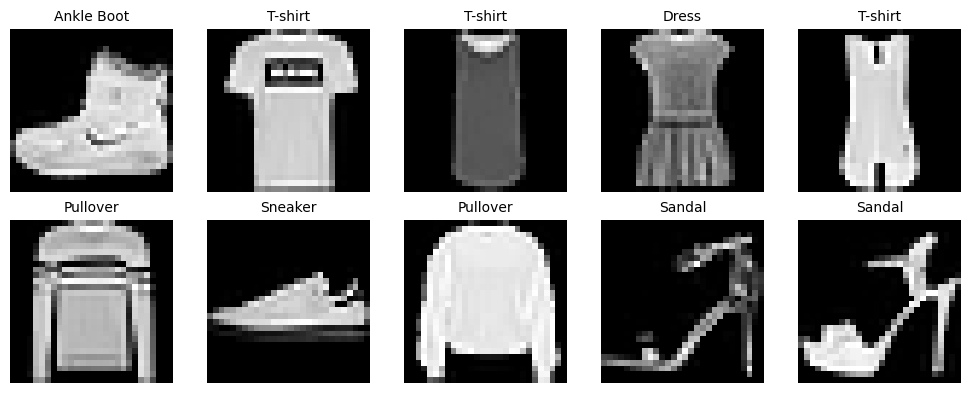

In [19]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Para acelerar la práctica utilizamos un subconjunto
train_dataset = torch.utils.data.Subset(train_dataset, range(10000))
test_dataset  = torch.utils.data.Subset(test_dataset, range(2000))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=256)

classes = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

fig, axes = plt.subplots(2,5, figsize=(10,4))

for ax, (img, label) in zip(axes.ravel(), train_dataset):

    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(classes[label], fontsize=10)
    ax.axis("off")

plt.tight_layout()

Entrenando MLP
Epoch 1 | Loss=0.836 | Acc=0.698
Epoch 2 | Loss=0.512 | Acc=0.814
Epoch 3 | Loss=0.452 | Acc=0.838
Epoch 4 | Loss=0.405 | Acc=0.853
Epoch 5 | Loss=0.384 | Acc=0.859
Epoch 6 | Loss=0.347 | Acc=0.874
Epoch 7 | Loss=0.323 | Acc=0.885
Epoch 8 | Loss=0.318 | Acc=0.889
Epoch 9 | Loss=0.300 | Acc=0.890
Epoch 10 | Loss=0.282 | Acc=0.898
Epoch 11 | Loss=0.261 | Acc=0.904
Epoch 12 | Loss=0.254 | Acc=0.908
Epoch 13 | Loss=0.241 | Acc=0.911
Epoch 14 | Loss=0.229 | Acc=0.916
Epoch 15 | Loss=0.224 | Acc=0.915
Epoch 16 | Loss=0.219 | Acc=0.918
Epoch 17 | Loss=0.205 | Acc=0.921
Epoch 18 | Loss=0.205 | Acc=0.926
Epoch 19 | Loss=0.190 | Acc=0.928
Epoch 20 | Loss=0.182 | Acc=0.934
Epoch 21 | Loss=0.173 | Acc=0.936
Epoch 22 | Loss=0.168 | Acc=0.937
Epoch 23 | Loss=0.158 | Acc=0.943
Epoch 24 | Loss=0.156 | Acc=0.942
Epoch 25 | Loss=0.146 | Acc=0.946
Epoch 26 | Loss=0.142 | Acc=0.946
Epoch 27 | Loss=0.146 | Acc=0.946
Epoch 28 | Loss=0.123 | Acc=0.957
Epoch 29 | Loss=0.126 | Acc=0.952
Epoch 30

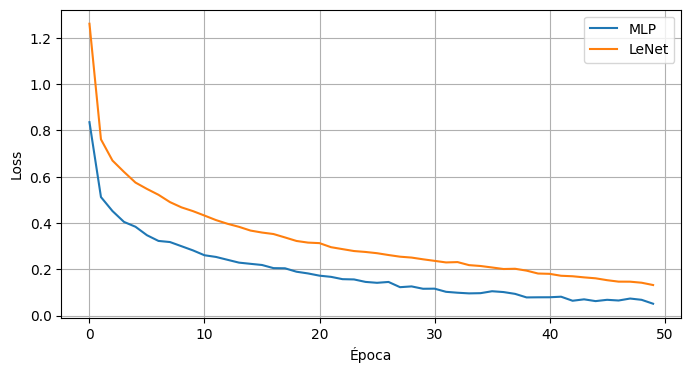

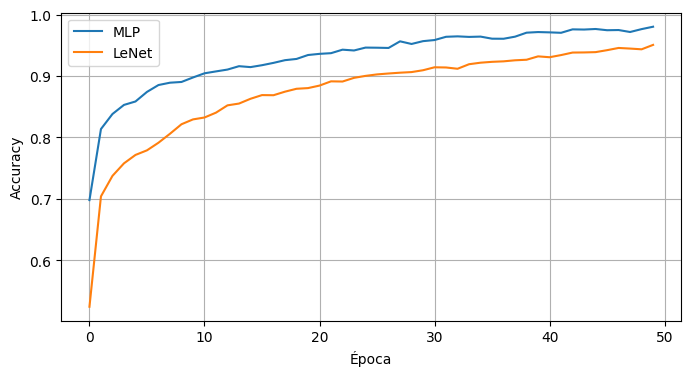

In [20]:
def train(model, epochs=50):

    model.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    criterion = nn.CrossEntropyLoss()

    history = {
        "loss":[],
        "acc":[]
    }

    start = time()

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for x,y in train_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()

            pred = model(x)

            loss = criterion(pred,y)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            correct += (pred.argmax(1)==y).sum().item()

            total += y.size(0)

        history["loss"].append(running_loss/len(train_loader))
        history["acc"].append(correct/total)

        print(
            f"Epoch {epoch+1} | "
            f"Loss={history['loss'][-1]:.3f} | "
            f"Acc={history['acc'][-1]:.3f}"
        )

    history["time"] = time()-start

    return history

def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x,y in loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            pred = model(x)

            correct += (pred.argmax(1)==y).sum().item()
            total += y.size(0)

    return correct/total

mlp = MLP()
cnn = LeNet()

print("Entrenando MLP")
hist_mlp = train(mlp, 50)

print()

print("Entrenando CNN")
hist_cnn = train(cnn, 50
)

plt.figure(figsize=(8,4))

plt.plot(hist_mlp["loss"], label="MLP")
plt.plot(hist_cnn["loss"], label="LeNet")

plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.figure(figsize=(8,4))

plt.plot(hist_mlp["acc"], label="MLP")
plt.plot(hist_cnn["acc"], label="LeNet")

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

acc_mlp = evaluate(mlp,test_loader)
acc_cnn = evaluate(cnn,test_loader)

print(f"MLP    : {acc_mlp:.3f}")
print(f"LeNet  : {acc_cnn:.3f}")

rot_transform = transforms.Compose([
    transforms.RandomRotation(25),
    transforms.ToTensor()
])

rot_dataset = datasets.FashionMNIST(
    "./data",
    train=False,
    transform=rot_transform
)

rot_dataset = torch.utils.data.Subset(rot_dataset, range(2000))

rot_loader = DataLoader(rot_dataset,batch_size=256)

print("Accuracy imágenes rotadas")

print(
    "MLP   :",
    evaluate(mlp,rot_loader)
)

print(
    "LeNet :",
    evaluate(cnn,rot_loader)
)

---
# 4. Arquitecturas profundas: VGG-16

LeNet demostró que las redes convolucionales eran capaces de aprender automáticamente características relevantes para clasificar imágenes. Sin embargo, su reducido número de capas limitaba la complejidad de los patrones que podía representar.

En 2014, investigadores de la Universidad de Oxford propusieron la familia de redes **VGG**, obteniendo resultados sobresalientes en el desafío **ImageNet Large Scale Visual Recognition Challenge (ILSVRC)**.

La principal contribución de **VGG-16** fue demostrar que una arquitectura **más profunda**, construida mediante la repetición de bloques convolucionales simples, podía aprender representaciones mucho más discriminativas sin necesidad de introducir componentes complejos.

A diferencia de LeNet, VGG utiliza únicamente:

- Convoluciones de **3×3**.
- Funciones de activación **ReLU**.
- Capas de **Max Pooling** para reducir la resolución.
- Capas totalmente conectadas únicamente al final de la red.

La arquitectura está formada por cinco bloques convolucionales que incrementan progresivamente el número de filtros mientras disminuyen la resolución espacial de la imagen.

Esta estrategia permite que las primeras capas aprendan bordes y texturas, mientras que las capas profundas detectan objetos y estructuras mucho más complejas.

In [26]:
class VGGSmall(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(32,32,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(128,128,3,padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128,256),

            nn.ReLU(),

            nn.Linear(256,10)
        )

    def forward(self,x):

        x = self.features(x)
        return self.classifier(x)

A partir de esta sección utilizaremos el conjunto de datos **CIFAR-10**, uno de los datasets más populares para el estudio y evaluación de redes neuronales convolucionales. CIFAR-10 fue desarrollado por investigadores del **Canadian Institute for Advanced Research (CIFAR)** y contiene un total de 60 000 imágenes **en color** distribuidas uniformemente en **10 categorías**. A diferencia de Fashion-MNIST, donde las imágenes muestran objetos centrados sobre un fondo prácticamente uniforme, CIFAR-10 presenta escenas mucho más variadas. Los objetos aparecen con diferentes posiciones, escalas, orientaciones e incluso distintos fondos, haciendo que la tarea de clasificación resulte considerablemente más desafiante.

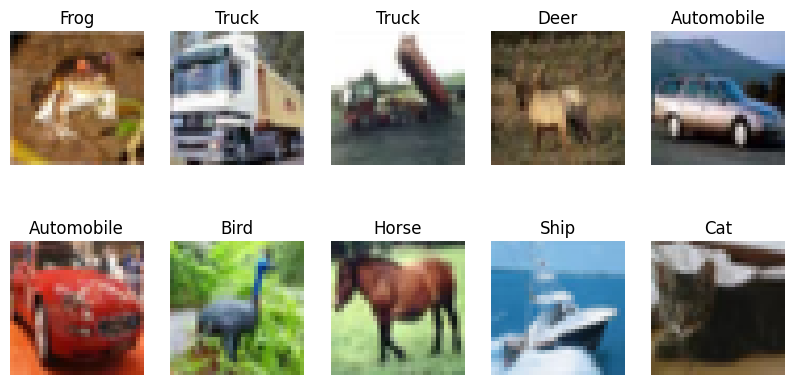

In [24]:
transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    "./data",
    train=True,
    download=True,
    transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = datasets.CIFAR10(
    "./data",
    train=False,
    download=True,
    transform=transform
)
test_loader  = DataLoader(test_dataset, batch_size=256)

classes = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

fig, axes = plt.subplots(2,5, figsize=(10,5))

for ax, (img,label) in zip(axes.ravel(), train_dataset):

    img = img.permute(1,2,0)

    ax.imshow(img)

    ax.set_title(classes[label])

    ax.axis("off")

In [27]:
vgg = VGGSmall().to(DEVICE)

history_vgg = train(vgg, epochs=10)

acc = evaluate(vgg, test_loader)

print(f"Accuracy: {acc:.3f}")

Epoch 1 | Loss=1.848 | Acc=0.287
Epoch 2 | Loss=1.444 | Acc=0.460
Epoch 3 | Loss=1.184 | Acc=0.566
Epoch 4 | Loss=1.031 | Acc=0.629
Epoch 5 | Loss=0.927 | Acc=0.668
Epoch 6 | Loss=0.846 | Acc=0.698
Epoch 7 | Loss=0.772 | Acc=0.726
Epoch 8 | Loss=0.705 | Acc=0.750
Epoch 9 | Loss=0.644 | Acc=0.773
Epoch 10 | Loss=0.591 | Acc=0.794
Accuracy: 0.764


---
# 5. El problema del *Vanishing Gradient* y ResNet

La evolución desde LeNet hasta VGG demostró que **incrementar la profundidad de una red** permitía aprender representaciones cada vez más complejas y mejorar el rendimiento en tareas de clasificación.

Podría parecer entonces que la solución consiste simplemente en seguir agregando capas. Sin embargo, al intentar entrenar redes muy profundas comenzó a aparecer un problema fundamental: **el entrenamiento dejaba de converger**.

Una de las principales causas es el denominado **vanishing gradient** (*desvanecimiento del gradiente*). Durante el entrenamiento, los parámetros de la red se actualizan mediante el algoritmo de **backpropagation**. En este proceso, el gradiente de la función de pérdida se propaga desde la salida hacia las primeras capas. Cuando la red contiene muchas capas, este gradiente se multiplica repetidamente por los pesos y por las derivadas de las funciones de activación. Si estos valores son menores que uno, el gradiente disminuye progresivamente hasta hacerse prácticamente nulo.

Como consecuencia:

- Las primeras capas dejan de aprender.
- El entrenamiento se vuelve extremadamente lento.
- Agregar más capas puede incluso empeorar el rendimiento del modelo.

Este fenómeno limitó durante muchos años la profundidad de las redes neuronales.

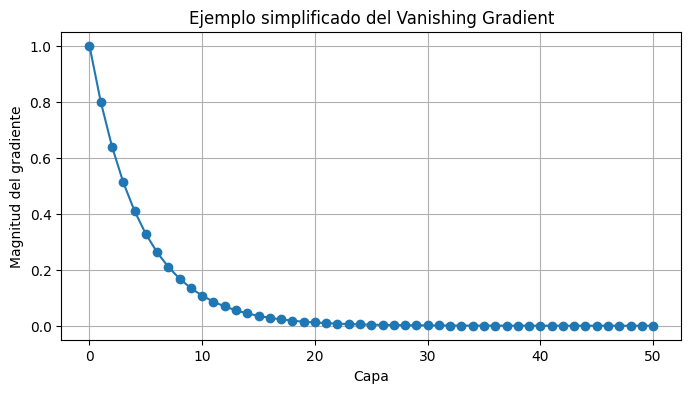

In [28]:
gradient = 1.0
gradients = [gradient]

for _ in range(50):
    gradient *= 0.8
    gradients.append(gradient)

plt.figure(figsize=(8,4))
plt.plot(gradients, marker="o")
plt.xlabel("Capa")
plt.ylabel("Magnitud del gradiente")
plt.title("Ejemplo simplificado del Vanishing Gradient")
plt.grid(True)

Incluso cuando el gradiente no desaparece completamente, las redes muy profundas presentan otro fenómeno conocido como **degradation problem**.

Al comparar dos modelos, una red de 20 capas y otra red de 50 capas, podría esperarse que la segunda obtuviera siempre un mejor rendimiento. Sin embargo, en la práctica ocurría lo contrario: la red más profunda obtenía un mayor error de entrenamiento.

Esto indicaba que el problema no era únicamente el sobreajuste, sino que las redes profundas eran cada vez más difíciles de optimizar.

En 2015, investigadores de Microsoft propusieron una idea sorprendentemente simple:

> En lugar de aprender directamente una función **H(x)**, la red aprende únicamente la diferencia respecto de la entrada.

Si llamamos **x** a la entrada de un bloque, la red intenta aprender:

$
F(x)=H(x)-x
$

De esta forma, la salida se calcula como:

$
H(x)=F(x)+x
$

La conexión que copia directamente la entrada hasta la salida se denomina **skip connection** o **conexión residual**.

Si las nuevas capas no resultan útiles, basta con aprender:

$
F(x)\approx0
$

y el bloque se comportará prácticamente como una identidad.

Gracias a esta idea, la información y el gradiente pueden propagarse mucho más fácilmente a través de la red, permitiendo entrenar modelos con decenas e incluso cientos de capas.

In [29]:
class ResidualBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.conv1 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1
        )

    def forward(self, x):

        identity = x

        out = self.conv1(x)
        out = self.relu(out)

        out = self.conv2(out)

        out = out + identity

        out = self.relu(out)

        return out
    
class MiniResNet(nn.Module):

    def __init__(self, num_classes=10):

        super().__init__()

        self.stem = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.layer1 = ResidualBlock(32)

        self.layer2 = ResidualBlock(32)

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Linear(32,num_classes)

    def forward(self,x):

        x = self.stem(x)

        x = self.layer1(x)

        x = self.layer2(x)

        x = self.pool(x)

        x = torch.flatten(x,1)

        return self.classifier(x)

---
# 6. Data Augmentation

Hasta ahora hemos mejorado nuestras redes neuronales diseñando arquitecturas cada vez más profundas y eficientes. Sin embargo, incluso el mejor modelo puede tener dificultades para generalizar si dispone de pocos ejemplos de entrenamiento o si las imágenes presentan variaciones que nunca observó durante el aprendizaje.

Una estrategia ampliamente utilizada para abordar este problema es el **Data Augmentation**, que consiste en generar sintéticamente nuevas muestras de entrenamiento aplicando transformaciones sobre las imágenes originales.

La idea es sencilla: en lugar de almacenar miles de imágenes adicionales, se crean nuevas variantes de cada imagen **durante el entrenamiento**, de modo que la red observa continuamente ejemplos ligeramente diferentes.

Estas transformaciones pueden simular situaciones habituales en aplicaciones reales, como:

- Pequeñas rotaciones.
- Cambios de escala.
- Traslaciones.
- Volteos horizontales.
- Variaciones de brillo y contraste.
- Recortes aleatorios.
- Adición de ruido.

El objetivo no es modificar la clase de la imagen, sino generar ejemplos diferentes que sigan representando el mismo objeto; de esta manera, el modelo aprende a reconocer el contenido independientemente de pequeñas variaciones presentes durante la adquisición de las imágenes.

Es importante prestar atención a qué tipo de transformaciones aplicar en función de la aplicación en que se usa. Por ejemplo, aplicar una transformación de rotación puede transformar un 6 en un 9 y confundir el entrenamiento del modelo.

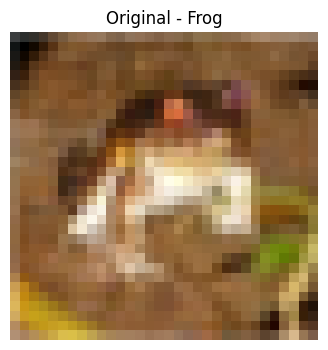

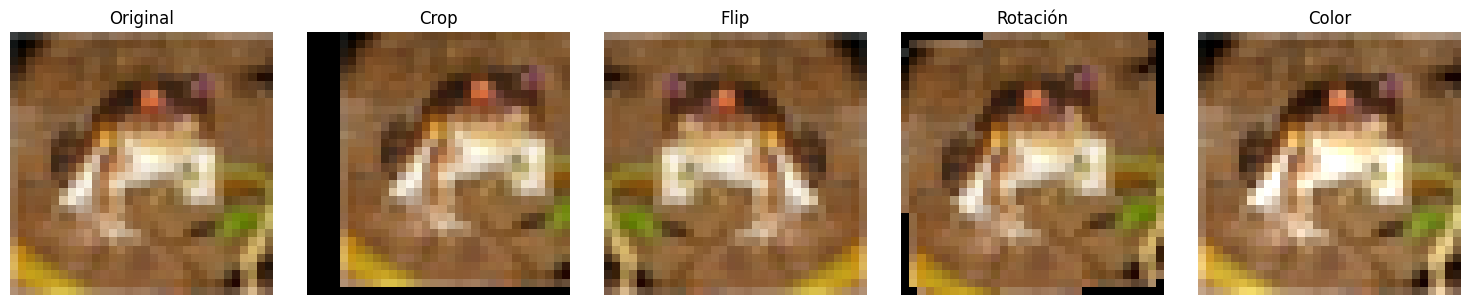

In [33]:
# ==========================================================
# Imagen de ejemplo
# ==========================================================

from torchvision.datasets import CIFAR10
from torchvision import transforms

# Dataset sin transformaciones (devuelve imágenes PIL)
raw_dataset = CIFAR10(
    "./data",
    train=True,
    download=True
)

pil_image, label = raw_dataset[0]

plt.figure(figsize=(4,4))
plt.imshow(pil_image)
plt.title(f"Original - {classes[label]}")
plt.axis("off")


# ==========================================================
# Distintas transformaciones
# ==========================================================

augmentations = {

    "Original":
        transforms.Compose([
            transforms.ToTensor()
        ]),

    "Crop":
        transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor()
        ]),

    "Flip":
        transforms.Compose([
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor()
        ]),

    "Rotación":
        transforms.Compose([
            transforms.RandomRotation(20),
            transforms.ToTensor()
        ]),

    "Color":
        transforms.Compose([
            transforms.ColorJitter(
                brightness=0.4,
                contrast=0.4,
                saturation=0.4
            ),
            transforms.ToTensor()
        ])
}

# ==========================================================
# Visualización
# ==========================================================

fig, axes = plt.subplots(1, len(augmentations), figsize=(15,3))

for ax, (name, transform) in zip(axes, augmentations.items()):

    img = transform(pil_image)

    ax.imshow(img.permute(1,2,0))
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()

---
# 7. Transfer Learning

Hasta ahora hemos entrenado todas las redes neuronales desde cero, inicializando sus pesos de forma aleatoria. Este enfoque funciona cuando se dispone de grandes conjuntos de datos, pero en muchos problemas reales sólo contamos con unos pocos cientos o miles de imágenes.

Una alternativa consiste en reutilizar modelos que ya fueron entrenados sobre enormes bases de datos, como **ImageNet**, que contiene más de un millón de imágenes distribuidas en 1000 categorías.

La idea detrás del **Transfer Learning** es que las primeras capas de una CNN aprenden características muy generales (bordes, texturas, esquinas, patrones repetitivos) que son útiles para una gran variedad de tareas de visión artificial.

En lugar de aprender nuevamente estas características desde cero, podemos reutilizar un modelo previamente entrenado y adaptarlo a nuestro problema.

De esta manera:

- Se reduce considerablemente el tiempo de entrenamiento.
- Se necesitan menos datos.
- Generalmente se obtiene un mejor rendimiento.

El proceso suele dividirse en dos etapas:

1. **Transfer Learning:** se congelan las capas convolucionales y únicamente se entrena un nuevo clasificador para las clases de interés.

2. **Fine Tuning:** posteriormente se descongelan algunas de las últimas capas para adaptarlas específicamente al nuevo dominio de imágenes.

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

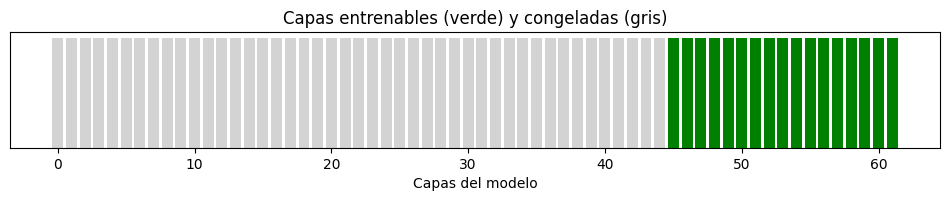

In [34]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

print(model)

import torch.nn as nn

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 10)

print(model.fc)

# Para ello, deshabilitamos el cálculo de gradientes de todas las capas convolucionales. 
# De esta manera únicamente se actualizarán los parámetros del nuevo clasificador.
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()

def train(model, train_loader, epochs=5):

    model.to(DEVICE)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3
    )

    criterion = nn.CrossEntropyLoss()

    history = {
        "loss": [],
        "acc": []
    }

    start = time()

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for x, y in train_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()

            pred = model(x)

            loss = criterion(pred, y)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            correct += (pred.argmax(1) == y).sum().item()
            total += y.size(0)

        history["loss"].append(running_loss / len(train_loader))
        history["acc"].append(correct / total)

        print(
            f"Epoch {epoch+1}/{epochs} "
            f"Loss={history['loss'][-1]:.3f} "
            f"Acc={history['acc'][-1]:.3f}"
        )

    history["time"] = time() - start

    return history

history_transfer = train(
    model,
    train_loader,
    epochs=5
)

# La idea consiste en descongelar únicamente las últimas capas convolucionales de la red, manteniendo congeladas las primeras. 
# Al ajustar únicamente estas últimas capas conseguimos adaptar la representación aprendida sin perder el conocimiento general 
# adquirido durante el entrenamiento sobre ImageNet.
for param in model.layer4.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(

    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),

    lr=1e-5
)

colors = []

for param in model.parameters():

    if param.requires_grad:
        colors.append("green")
    else:
        colors.append("lightgray")

plt.figure(figsize=(12,1.5))

plt.bar(
    range(len(colors)),
    [1]*len(colors),
    color=colors
)

plt.yticks([])
plt.xlabel("Capas del modelo")
plt.title("Capas entrenables (verde) y congeladas (gris)")
plt.show()

---
# 8. Evaluación de modelos de clasificación

Entrenar una red neuronal es sólo una parte del proceso de desarrollo de un sistema de visión artificial. Una vez finalizado el entrenamiento, es necesario evaluar objetivamente el desempeño del modelo para determinar si resulta adecuado para la aplicación.

Aunque la **accuracy** suele ser la métrica más utilizada, rara vez es suficiente para describir completamente el comportamiento de un clasificador.

Dependiendo del problema, pueden resultar igualmente importantes:

- La cantidad de falsos positivos y falsos negativos.
- El tiempo necesario para entrenar el modelo.
- La velocidad de inferencia.
- El tamaño del modelo.
- La cantidad de parámetros entrenables.
- La capacidad de generalización sobre imágenes no vistas.

## 8.1 Accuracy

La **accuracy** representa la proporción de imágenes correctamente clasificadas respecto del total de ejemplos evaluados.

$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$

Es una métrica sencilla de interpretar y muy utilizada cuando las clases poseen una distribución relativamente equilibrada.

Sin embargo, puede resultar engañosa cuando algunas clases aparecen con mucha mayor frecuencia que otras.

In [35]:
def accuracy(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            pred = model(x).argmax(1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    return correct / total


## 8.2 Matriz de confusión

Mientras que la accuracy resume el rendimiento en un único número, la **matriz de confusión** muestra detalladamente qué clases son confundidas entre sí.

Cada fila representa la clase verdadera y cada columna la clase predicha.

Una matriz ideal presenta todos sus valores concentrados sobre la diagonal principal.

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for x,y in loader:

            pred = model(x.to(DEVICE)).argmax(1)

            y_true.extend(y.numpy())
            y_pred.extend(pred.cpu().numpy())

    cm = confusion_matrix(y_true,y_pred)

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=classes
    )

    fig, ax = plt.subplots(figsize=(8,8))
    disp.plot(
        xticks_rotation=45,
        cmap="Blues",
        ax=ax
    )

## 8.3 Precision, Recall y F1-Score

En muchos problemas no todos los errores tienen la misma importancia.

Por ejemplo, en un sistema de diagnóstico médico puede ser mucho más grave no detectar una enfermedad que generar una falsa alarma.

Para este tipo de aplicaciones se utilizan métricas derivadas de la matriz de confusión.

**Precision**

Mide qué proporción de las predicciones positivas fueron realmente correctas.

$
Precision=\frac{TP}{TP+FP}
$

**Recall**

Mide qué proporción de los ejemplos positivos fue correctamente detectada.

$
Recall=\frac{TP}{TP+FN}
$

**F1-Score**

Corresponde a la media armónica entre Precision y Recall.

$
F1=
2
\frac{Precision\cdot Recall}
{Precision+Recall}
$

In [37]:
from sklearn.metrics import classification_report

def classification_metrics(model, loader):

    model.eval()

    y_true=[]
    y_pred=[]

    with torch.no_grad():

        for x,y in loader:

            pred=model(x.to(DEVICE)).argmax(1)

            y_true.extend(y.numpy())
            y_pred.extend(pred.cpu().numpy())

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=classes
        )
    )

## 8.4 Evolución del entrenamiento

El análisis de las curvas de entrenamiento permite identificar problemas como:

- Sobreajuste (*Overfitting*).
- Subajuste (*Underfitting*).
- Convergencia lenta.
- Estancamiento del aprendizaje.

Generalmente se representan la pérdida (*Loss*) y la precisión (*Accuracy*) tanto para entrenamiento como para validación.

In [38]:
plt.figure(figsize=(8,4))

plt.plot(history["train_loss"],label="Train")

plt.plot(history["val_loss"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.legend()

NameError: name 'history' is not defined

<Figure size 800x400 with 0 Axes>

## 8.5 Tiempo de entrenamiento

Además del rendimiento predictivo, resulta importante considerar el costo computacional del entrenamiento.

Arquitecturas más profundas suelen requerir un mayor tiempo para converger, aunque frecuentemente obtienen mejores resultados.

Durante el entrenamiento registramos automáticamente el tiempo requerido por cada modelo.

In [ ]:
results = {

    "MLP":hist_mlp,

    "LeNet":hist_lenet,

    "VGG":hist_vgg,

    "MiniResNet":hist_resnet,

    "Transfer":hist_transfer
}

for model_name,data in results.items():

    print(
        f"{model_name:15}"
        f"{data['time']:.1f} s"
    )

## 8.6 Tiempo de inferencia

En muchas aplicaciones en tiempo real —como conducción autónoma, videovigilancia o robótica— el tiempo necesario para clasificar una imagen puede ser tan importante como la precisión obtenida.

Para estimar este costo mediremos el tiempo promedio requerido para procesar una imagen.

In [ ]:
import time

def inference_time(model, loader, repetitions=10):

    model.eval()

    x, _ = next(iter(loader))
    x = x.to(DEVICE)

    # Calentamiento (warm-up)
    with torch.no_grad():
        for _ in range(5):
            _ = model(x)

    start = time.perf_counter()

    with torch.no_grad():
        for _ in range(repetitions):
            _ = model(x)

    end = time.perf_counter()

    elapsed = (end - start) / repetitions
    per_image = elapsed / x.shape[0]

    return elapsed, per_image

for name, model in {

    "MLP": mlp,
    "LeNet": lenet,
    "VGG": vgg,
    "MiniResNet": mini_resnet

}.items():

    batch_time, image_time = inference_time(model, test_loader)

    print(
        f"{name:12}"
        f"{batch_time*1000:8.2f} ms/batch   "
        f"{image_time*1000:.3f} ms/img"
    )

In [ ]:
import pandas as pd

summary = pd.DataFrame({

    "Modelo":[
        "MLP",
        "LeNet",
        "VGG",
        "MiniResNet"
    ],

    "Accuracy":[
        accuracy(mlp,test_loader),
        accuracy(lenet,test_loader),
        accuracy(vgg,test_loader),
        accuracy(mini_resnet,test_loader)
    ],

    "Parámetros":[
        count_parameters(mlp),
        count_parameters(lenet),
        count_parameters(vgg),
        count_parameters(mini_resnet)
    ],

    "Entrenamiento (s)":[
        hist_mlp["time"],
        hist_lenet["time"],
        hist_vgg["time"],
        hist_resnet["time"]
    ]
})

summary